Training net 1/5
Training net 2/5
Training net 3/5
Training net 4/5
Training net 5/5


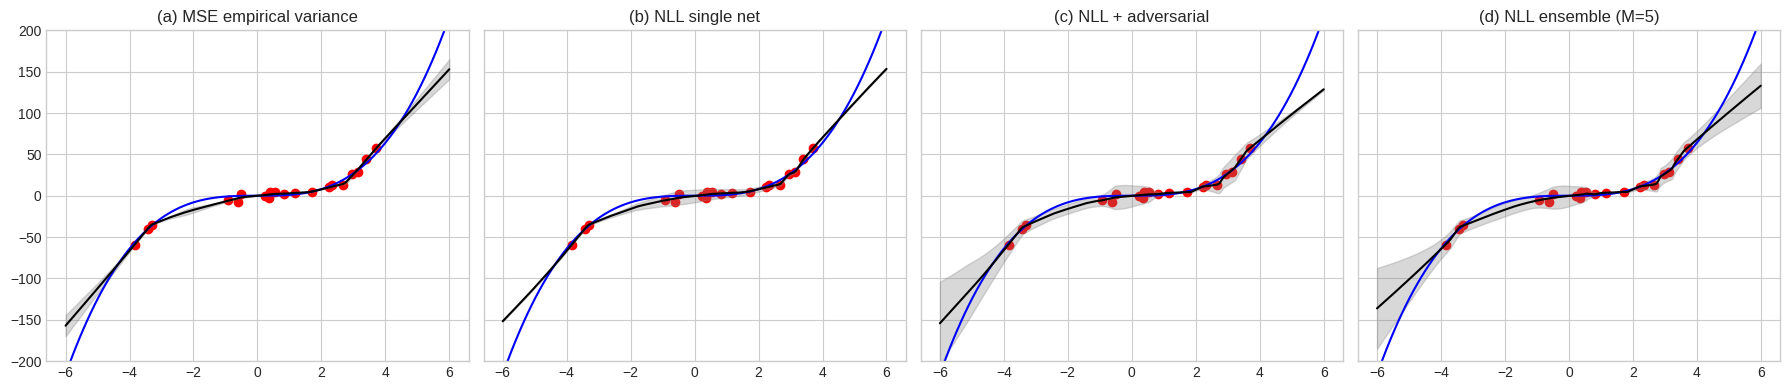

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")

# ============================================================
# 1. Toy dataset (same as paper)
# ============================================================
def make_toy_data(n=20, noise_std=3.0, seed=0):
    rng = np.random.RandomState(seed)
    x = rng.uniform(-4, 4, size=(n, 1))
    y = x**3 + rng.normal(0, noise_std, size=(n, 1))
    return x.astype(np.float32), y.astype(np.float32)

x_train, y_train = make_toy_data()

# Normalize (VERY IMPORTANT)
x_mean, x_std = x_train.mean(), x_train.std()
y_mean, y_std = y_train.mean(), y_train.std()

x_train_n = (x_train - x_mean) / x_std
y_train_n = (y_train - y_mean) / y_std

x_train_t = torch.from_numpy(x_train_n)
y_train_t = torch.from_numpy(y_train_n)

# ============================================================
# 2. Probabilistic network (with softplus variance)
# ============================================================
class ProbRegNet(nn.Module):
    def __init__(self, hidden=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
        )
        self.mu_head = nn.Linear(hidden, 1)
        self.log_var_head = nn.Linear(hidden, 1)

    def forward(self, x):
        h = self.net(x)
        mu = self.mu_head(h)
        log_var = self.log_var_head(h)
        var = torch.nn.functional.softplus(log_var) + 1e-6
        return mu, var

# ============================================================
# 3. NLL loss + adversarial examples
# ============================================================
def nll_loss(y, mu, var):
    return (0.5 * torch.log(var) + 0.5 * (y - mu)**2 / var).mean()

def make_adv(model, x, y, eps=0.05):
    x_adv = x.clone().detach().requires_grad_(True)
    mu, var = model(x_adv)
    loss = nll_loss(y, mu, var)
    grad = torch.autograd.grad(loss, x_adv)[0]
    return (x_adv + eps * grad.sign()).detach()

# ============================================================
# 4. Training functions
# ============================================================
def train_single(model, x, y, epochs=4000, lr=1e-3, use_adv=False):
    opt = optim.Adam(model.parameters(), lr=lr)
    for _ in range(epochs):
        if use_adv:
            x_adv = make_adv(model, x, y)
            x_all = torch.cat([x, x_adv], dim=0)
            y_all = torch.cat([y, y], dim=0)
        else:
            x_all, y_all = x, y

        mu, var = model(x_all)
        loss = nll_loss(y_all, mu, var)

        opt.zero_grad()
        loss.backward()
        opt.step()
    return model

def build_ensemble(M=5):
    return [ProbRegNet() for _ in range(M)]

def train_ensemble(nets, x, y, **kwargs):
    for i, net in enumerate(nets):
        print(f"Training net {i+1}/{len(nets)}")
        train_single(net, x, y, **kwargs)
    return nets

# ============================================================
# 5. Prediction helpers
# ============================================================
def ensemble_predict(nets, x):
    mus, vars_ = [], []
    for net in nets:
        net.eval()
        with torch.no_grad():
            mu, var = net(x)
            mus.append(mu)
            vars_.append(var)
    mus = torch.stack(mus)
    vars_ = torch.stack(vars_)
    mu_ens = mus.mean(0)
    var_ens = (vars_ + (mus - mu_ens)**2).mean(0)
    return mu_ens, var_ens

# ============================================================
# 6. Run all four experiments
# ============================================================
x_test = np.linspace(-6, 6, 200).astype(np.float32).reshape(-1, 1)
x_test_n = (x_test - x_mean) / x_std
x_test_t = torch.from_numpy(x_test_n)

# (a) MSE empirical variance
nets_mse = [nn.Sequential(nn.Linear(1, 100), nn.ReLU(), nn.Linear(100, 1)) for _ in range(5)]
for net in nets_mse:
    opt = optim.Adam(net.parameters(), lr=1e-3)
    for _ in range(4000):
        y_pred = net(x_train_t)
        loss = ((y_pred - y_train_t)**2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()

mus = torch.stack([net(x_test_t).detach() for net in nets_mse])
mu_mse = mus.mean(0)
std_mse = mus.std(0)

# (b) NLL single net
net_nll = ProbRegNet()
train_single(net_nll, x_train_t, y_train_t)
mu_nll, var_nll = net_nll(x_test_t)
std_nll = var_nll.sqrt().detach()

# (c) NLL + adversarial
net_adv = ProbRegNet()
train_single(net_adv, x_train_t, y_train_t, use_adv=True)
mu_adv, var_adv = net_adv(x_test_t)
std_adv = var_adv.sqrt().detach()

# (d) NLL ensemble
nets_ens = build_ensemble()
train_ensemble(nets_ens, x_train_t, y_train_t, use_adv=True)
mu_ens, var_ens = ensemble_predict(nets_ens, x_test_t)
std_ens = var_ens.sqrt().detach()

# ============================================================
# 7. Unnormalize (FIXED VERSION)
# ============================================================
def unnormalize(mu, std):
    mu = mu.detach() * y_std + y_mean
    std = std.detach() * y_std
    return mu.numpy(), std.numpy()

mu_mse_u, std_mse_u = unnormalize(mu_mse, std_mse)
mu_nll_u, std_nll_u = unnormalize(mu_nll, std_nll)
mu_adv_u, std_adv_u = unnormalize(mu_adv, std_adv)
mu_ens_u, std_ens_u = unnormalize(mu_ens, std_ens)

# ============================================================
# 8. Plotting
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

def plot(ax, mu, std, title):
    ax.plot(x_test, x_test**3, 'b-', label='True f(x)')
    ax.scatter(x_train, y_train, color='red')
    ax.plot(x_test, mu, 'k-')
    ax.fill_between(x_test.squeeze(),
                    mu.squeeze() - 3*std.squeeze(),
                    mu.squeeze() + 3*std.squeeze(),
                    color='gray', alpha=0.3)
    ax.set_title(title)
    ax.set_ylim(-200, 200)

plot(axes[0], mu_mse_u, std_mse_u, "(a) MSE empirical variance")
plot(axes[1], mu_nll_u, std_nll_u, "(b) NLL single net")
plot(axes[2], mu_adv_u, std_adv_u, "(c) NLL + adversarial")
plot(axes[3], mu_ens_u, std_ens_u, "(d) NLL ensemble (M=5)")

plt.tight_layout()
plt.show()


In [5]:
!pip install -q openml

import openml
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class ProbRegNet(nn.Module):
    def __init__(self, input_dim, hidden=50):
        super().__init__()
        self.hidden = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
        )
        self.mu = nn.Linear(hidden, 1)
        self.log_var = nn.Linear(hidden, 1)

    def forward(self, x):
        h = self.hidden(x)
        mu = self.mu(h)
        log_var = self.log_var(h)
        var = torch.nn.functional.softplus(log_var) + 1e-6
        return mu, var

def nll_loss(y, mu, var):
    return (0.5 * torch.log(var) + 0.5 * (y - mu)**2 / var).mean()

def make_adv(model, x, y, eps):
    x_adv = x.clone().detach().requires_grad_(True)
    mu, var = model(x_adv)
    loss = nll_loss(y, mu, var)
    grad = torch.autograd.grad(loss, x_adv)[0]
    return (x_adv + eps * grad.sign()).detach()

def train_single(model, X_train, y_train, eps, epochs=40, lr=1e-3):
    model.to(device)
    X_t = torch.from_numpy(X_train).to(device)
    y_t = torch.from_numpy(y_train).to(device)
    opt = optim.Adam(model.parameters(), lr=lr)

    for _ in range(epochs):
        x_adv = make_adv(model, X_t, y_t, eps)
        X_all = torch.cat([X_t, x_adv], dim=0)
        y_all = torch.cat([y_t, y_t], dim=0)

        mu, var = model(X_all)
        loss = nll_loss(y_all, mu, var)

        opt.zero_grad()
        loss.backward()
        opt.step()

def train_ensemble(X_train, y_train, eps, input_dim, hidden):
    nets = [ProbRegNet(input_dim, hidden) for _ in range(5)]
    for i, net in enumerate(nets):
        print(f"  Training net {i+1}/5")
        train_single(net, X_train, y_train, eps)
    return nets

def ensemble_predict(nets, X_test):
    X_t = torch.from_numpy(X_test).to(device)
    mus, vars_ = [], []

    for net in nets:
        net.eval()
        net.to(device)
        with torch.no_grad():
            mu, var = net(X_t)
            mus.append(mu.cpu())
            vars_.append(var.cpu())

    mus = torch.stack(mus)
    vars_ = torch.stack(vars_)

    mu_ens = mus.mean(0).numpy()
    var_ens = (vars_ + (mus - mu_ens)**2).mean(0).numpy()
    return mu_ens, var_ens

def rmse(y, y_pred):
    return math.sqrt(mean_squared_error(y, y_pred))

def nll(y, mu, var):
    return (0.5*np.log(var) + 0.5*(y - mu)**2 / var).mean()

# ONLY WORKING DATASETS
uci_datasets = {
    "boston":   531,
    "concrete": 1030,
    "energy":   1472,
    "kin8nm":   189,
    "power":    1471,
    "wine":     287,
}

results = {}

for name, did in uci_datasets.items():
    print(f"\n=== Dataset: {name} (OpenML ID {did}) ===")

    dataset = openml.datasets.get_dataset(did)
    X, y, _, _ = dataset.get_data(target=dataset.default_target_attribute)

    X = np.array(X).astype(np.float32)
    y = np.array(y).astype(np.float32).reshape(-1, 1)

    input_dim = X.shape[1]
    n_splits = 20

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=0)
    rmse_scores = []
    nll_scores = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
        print(f" Fold {fold}/{n_splits}")

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        sx = StandardScaler().fit(X_train)
        sy = StandardScaler().fit(y_train)

        X_train_n = sx.transform(X_train)
        X_test_n = sx.transform(X_test)
        y_train_n = sy.transform(y_train)
        y_test_n = sy.transform(y_test)

        eps = 0.01 * (X_train_n.max() - X_train_n.min())
        hidden = 50

        nets = train_ensemble(X_train_n, y_train_n, eps, input_dim, hidden)

        mu, var = ensemble_predict(nets, X_test_n)

        mu = sy.inverse_transform(mu)
        var = var * (sy.scale_**2)

        rmse_scores.append(rmse(y_test, mu))
        nll_scores.append(nll(y_test, mu, var))

    results[name] = (
        np.mean(rmse_scores), np.std(rmse_scores),
        np.mean(nll_scores), np.std(nll_scores)
    )

print("\n=== Final Results: Deep Ensembles (6 OpenML UCI datasets) ===")
print(f"{'Dataset':10s}  {'RMSE (mean±std)':25s}  {'NLL (mean±std)':25s}")
for name, (rm, rs, nl, ns) in results.items():
    print(f"{name:10s}  {rm:.3f} ± {rs:.3f}        {nl:.3f} ± {ns:.3f}")


Using device: cpu

=== Dataset: boston (OpenML ID 531) ===
 Fold 1/20
  Training net 1/5
  Training net 2/5
  Training net 3/5
  Training net 4/5
  Training net 5/5
 Fold 2/20
  Training net 1/5
  Training net 2/5


/tmp/ipykernel_57/202642638.py:85: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  var_ens = (vars_ + (mus - mu_ens)**2).mean(0).numpy()


  Training net 3/5
  Training net 4/5
  Training net 5/5
 Fold 3/20
  Training net 1/5
  Training net 2/5


/tmp/ipykernel_57/202642638.py:85: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  var_ens = (vars_ + (mus - mu_ens)**2).mean(0).numpy()


  Training net 3/5
  Training net 4/5
  Training net 5/5
 Fold 4/20
  Training net 1/5


...

/tmp/ipykernel_57/202642638.py:85: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  var_ens = (vars_ + (mus - mu_ens)**2).mean(0).numpy()


 Fold 19/20
  Training net 1/5
  Training net 2/5
  Training net 3/5
  Training net 4/5
  Training net 5/5


/tmp/ipykernel_57/202642638.py:85: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  var_ens = (vars_ + (mus - mu_ens)**2).mean(0).numpy()


 Fold 20/20
  Training net 1/5
  Training net 2/5
  Training net 3/5
  Training net 4/5
  Training net 5/5

=== Final Results: Deep Ensembles (6 OpenML UCI datasets) ===
Dataset     RMSE (mean±std)            NLL (mean±std)           
boston      6.045 ± 1.463        2.326 ± 0.117
concrete    1.692 ± 0.129        1.025 ± 0.066
energy      6.166 ± 1.280        2.366 ± 0.100
kin8nm      0.222 ± 0.008        -1.008 ± 0.031
power       1.510 ± 3.032        -0.177 ± 0.010
wine        0.781 ± 0.041        0.252 ± 0.048


/tmp/ipykernel_57/202642638.py:85: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  var_ens = (vars_ + (mus - mu_ens)**2).mean(0).numpy()


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
from math import log

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------- Metrics ----------

def nll_loss_logits(logits, targets):
    # logits: [N, K], targets: [N]
    return F.cross_entropy(logits, targets, reduction="mean")

def brier_score(probs, targets, num_classes=10):
    # probs: [N, K], targets: [N]
    one_hot = F.one_hot(targets, num_classes=num_classes).float()
    return ((one_hot - probs) ** 2).sum(dim=1).mean().item()

def accuracy(probs, targets):
    preds = probs.argmax(dim=1)
    return (preds == targets).float().mean().item()

# ---------- Adversarial examples (FGSM-style) ----------

def make_adv_examples(model, x, y, epsilon):
    x_adv = x.clone().detach().requires_grad_(True)
    logits = model(x_adv)
    loss = nll_loss_logits(logits, y)
    grad = torch.autograd.grad(loss, x_adv)[0]
    x_adv = x_adv + epsilon * grad.sign()
    x_adv = torch.clamp(x_adv, 0.0, 1.0)
    return x_adv.detach()

def make_random_signed_examples(x, epsilon):
    noise = epsilon * torch.sign(torch.randn_like(x))
    x_rand = x + noise
    x_rand = torch.clamp(x_rand, 0.0, 1.0)
    return x_rand.detach()


Using device: cuda


In [2]:
class MLP3(nn.Module):
    def __init__(self, input_dim=28*28, hidden=200, num_classes=10, dropout_p=0.0):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden)
        self.bn1 = nn.BatchNorm1d(hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.bn2 = nn.BatchNorm1d(hidden)
        self.fc3 = nn.Linear(hidden, hidden)
        self.bn3 = nn.BatchNorm1d(hidden)
        self.out = nn.Linear(hidden, num_classes)
        self.dropout_p = dropout_p

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.bn1(self.fc1(x)))
        if self.dropout_p > 0:
            x = F.dropout(x, p=self.dropout_p, training=self.training)
        x = F.relu(self.bn2(self.fc2(x)))
        if self.dropout_p > 0:
            x = F.dropout(x, p=self.dropout_p, training=self.training)
        x = F.relu(self.bn3(self.fc3(x)))
        if self.dropout_p > 0:
            x = F.dropout(x, p=self.dropout_p, training=self.training)
        logits = self.out(x)
        return logits


In [7]:
batch_size = 100

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=1000, shuffle=False, num_workers=2)


100%|██████████| 9.91M/9.91M [00:00<00:00, 132MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 39.7MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 102MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.4MB/s]


In [3]:
def train_single_net(
    model, train_loader, epochs=40, lr=1e-3,
    adv_mode=None, epsilon=0.0
):
    """
    adv_mode: None | 'adv' | 'random'
    """
    model.to(device)
    model.train()
    opt = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            if adv_mode == "adv":
                x_adv = make_adv_examples(model, x, y, epsilon)
                x_all = torch.cat([x, x_adv], dim=0)
                y_all = torch.cat([y, y], dim=0)
            elif adv_mode == "random":
                x_rand = make_random_signed_examples(x, epsilon)
                x_all = torch.cat([x, x_rand], dim=0)
                y_all = torch.cat([y, y], dim=0)
            else:
                x_all, y_all = x, y

            logits = model(x_all)
            loss = nll_loss_logits(logits, y_all)

            opt.zero_grad()
            loss.backward()
            opt.step()

    return model


def evaluate_ensemble(models, test_loader, num_classes=10):
    for m in models:
        m.eval()
        m.to(device)

    all_probs = []
    all_targets = []

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            logits_list = []
            for m in models:
                logits_list.append(m(x))
            logits_stack = torch.stack(logits_list, dim=0)  # [M, N, K]
            probs_stack = F.softmax(logits_stack, dim=-1)
            probs_mean = probs_stack.mean(dim=0)  # [N, K]

            all_probs.append(probs_mean.cpu())
            all_targets.append(y)

    all_probs = torch.cat(all_probs, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    acc = accuracy(all_probs, all_targets)
    bs  = brier_score(all_probs, all_targets, num_classes=num_classes)
    # NLL: use mean log prob of true class
    log_probs = torch.log(all_probs + 1e-8)
    nll = F.nll_loss(log_probs, all_targets, reduction="mean").item()

    return acc, nll, bs


def evaluate_mc_dropout(model, test_loader, M=5, num_classes=10):
    model.to(device)
    model.train()  # keep dropout ON

    all_probs = []
    all_targets = []

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            logits_list = []
            for _ in range(M):
                logits_list.append(model(x))
            logits_stack = torch.stack(logits_list, dim=0)
            probs_stack = F.softmax(logits_stack, dim=-1)
            probs_mean = probs_stack.mean(dim=0)

            all_probs.append(probs_mean.cpu())
            all_targets.append(y)

    all_probs = torch.cat(all_probs, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    acc = accuracy(all_probs, all_targets)
    bs  = brier_score(all_probs, all_targets, num_classes=num_classes)
    log_probs = torch.log(all_probs + 1e-8)
    nll = F.nll_loss(log_probs, all_targets, reduction="mean").item()

    return acc, nll, bs


In [5]:
# ============================
# 0. Setup
# ============================
epsilon = 0.01
Ms = [1, 3, 5, 10, 15]

results_mnist = {
    "ensemble": [],
    "ensemble_random": [],
    "ensemble_adv": [],
    "mc_dropout": [],
}

# ============================
# 1. Pre-train all networks ONCE
# ============================

NUM_NETS = max(Ms)   # 15 networks total

print("Training base networks...")

base_nets = []
base_nets_random = []
base_nets_adv = []

for i in range(NUM_NETS):
    print(f"Training base net {i+1}/{NUM_NETS}")

    # ----- Plain network -----
    net_plain = MLP3(dropout_p=0.0)
    net_plain = train_single_net(net_plain, train_loader, epochs=10, lr=1e-3,
                                 adv_mode=None, epsilon=0.0)
    base_nets.append(net_plain)

    # ----- Random direction -----
    net_rand = MLP3(dropout_p=0.0)
    net_rand = train_single_net(net_rand, train_loader, epochs=10, lr=1e-3,
                                adv_mode="random", epsilon=epsilon)
    base_nets_random.append(net_rand)

    # ----- Adversarial training -----
    net_adv = MLP3(dropout_p=0.0)
    net_adv = train_single_net(net_adv, train_loader, epochs=10, lr=1e-3,
                               adv_mode="adv", epsilon=epsilon)
    base_nets_adv.append(net_adv)

print("Finished training all base networks.")

# ============================
# 2. Train MC-Dropout model ONCE
# ============================

print("Training MC-Dropout model...")
mc_model = MLP3(dropout_p=0.1)
mc_model = train_single_net(mc_model, train_loader, epochs=10, lr=1e-3,
                            adv_mode=None, epsilon=0.0)

# ============================
# 3. Evaluate for each M
# ============================

for M in Ms:
    print(f"\n=== MNIST: M = {M} ===")

    # ----- Ensemble -----
    acc, nll, bs = evaluate_ensemble(base_nets[:M], test_loader)
    results_mnist["ensemble"].append((acc, nll, bs))
    print(f"Ensemble: acc={acc:.4f}, nll={nll:.4f}, brier={bs:.4f}")

    # ----- Ensemble + random -----
    acc, nll, bs = evaluate_ensemble(base_nets_random[:M], test_loader)
    results_mnist["ensemble_random"].append((acc, nll, bs))
    print(f"Ensemble+Random: acc={acc:.4f}, nll={nll:.4f}, brier={bs:.4f}")

    # ----- Ensemble + adversarial -----
    acc, nll, bs = evaluate_ensemble(base_nets_adv[:M], test_loader)
    results_mnist["ensemble_adv"].append((acc, nll, bs))
    print(f"Ensemble+AT: acc={acc:.4f}, nll={nll:.4f}, brier={bs:.4f}")

    # ----- MC-Dropout -----
    acc, nll, bs = evaluate_mc_dropout(mc_model, test_loader, M=M)
    results_mnist["mc_dropout"].append((acc, nll, bs))
    print(f"MC-Dropout: acc={acc:.4f}, nll={nll:.4f}, brier={bs:.4f}")


Training base networks...
Training base net 1/15
Training base net 2/15
Training base net 3/15
Training base net 4/15
Training base net 5/15
Training base net 6/15
Training base net 7/15
Training base net 8/15
Training base net 9/15
Training base net 10/15
Training base net 11/15
Training base net 12/15
Training base net 13/15
Training base net 14/15
Training base net 15/15
Finished training all base networks.
Training MC-Dropout model...

=== MNIST: M = 1 ===
Ensemble: acc=0.9801, nll=0.0714, brier=0.0313
Ensemble+Random: acc=0.9816, nll=0.0696, brier=0.0298
Ensemble+AT: acc=0.9842, nll=0.0524, brier=0.0247
MC-Dropout: acc=0.9770, nll=0.0857, brier=0.0367

=== MNIST: M = 3 ===
Ensemble: acc=0.9863, nll=0.0470, brier=0.0219
Ensemble+Random: acc=0.9865, nll=0.0468, brier=0.0221
Ensemble+AT: acc=0.9875, nll=0.0388, brier=0.0195
MC-Dropout: acc=0.9797, nll=0.0701, brier=0.0318

=== MNIST: M = 5 ===
Ensemble: acc=0.9866, nll=0.0429, brier=0.0206
Ensemble+Random: acc=0.9877, nll=0.0426, bri

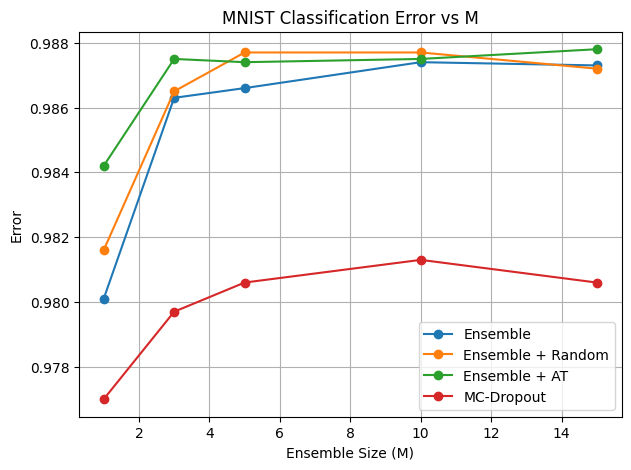

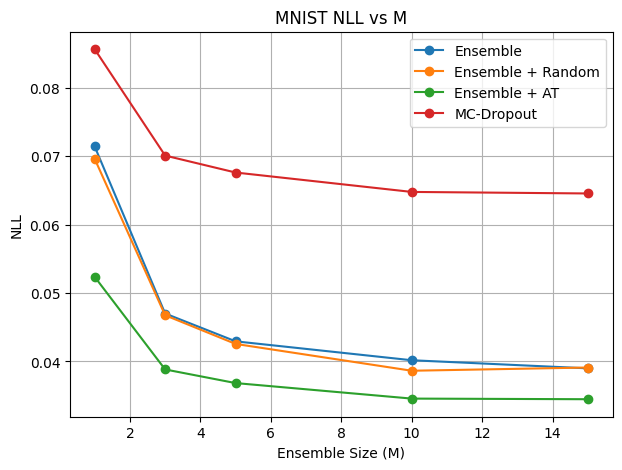

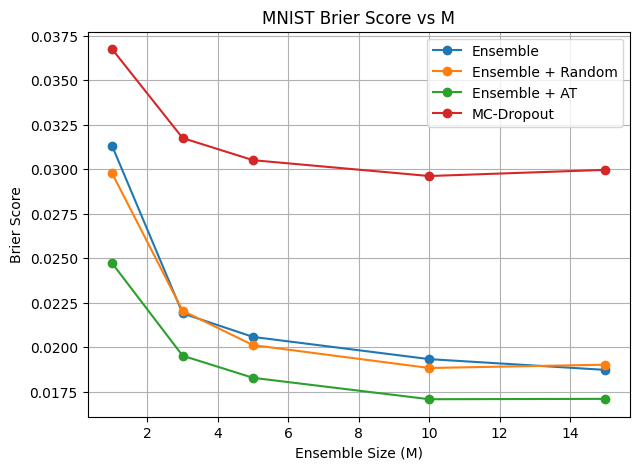

In [7]:
import matplotlib.pyplot as plt

def plot_metric(Ms, results, metric_index, title, ylabel):
    plt.figure(figsize=(7,5))

    plt.plot(Ms, [results["ensemble"][i][metric_index] for i in range(len(Ms))],
             label="Ensemble", marker="o")
    plt.plot(Ms, [results["ensemble_random"][i][metric_index] for i in range(len(Ms))],
             label="Ensemble + Random", marker="o")
    plt.plot(Ms, [results["ensemble_adv"][i][metric_index] for i in range(len(Ms))],
             label="Ensemble + AT", marker="o")
    plt.plot(Ms, [results["mc_dropout"][i][metric_index] for i in range(len(Ms))],
             label="MC-Dropout", marker="o")

    plt.title(title)
    plt.xlabel("Ensemble Size (M)")
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.legend()
    plt.show()

# Plot for MNIST
plot_metric(Ms, results_mnist, 0, "MNIST Classification Error vs M", "Error")
plot_metric(Ms, results_mnist, 1, "MNIST NLL vs M", "NLL")
plot_metric(Ms, results_mnist, 2, "MNIST Brier Score vs M", "Brier Score")


In [4]:
from torchvision.datasets import SVHN

svhn_train = SVHN(root="./data", split="train", download=True,
                  transform=transforms.ToTensor())
svhn_test  = SVHN(root="./data", split="test", download=True,
                  transform=transforms.ToTensor())

svhn_train_loader = DataLoader(svhn_train, batch_size=100, shuffle=True, num_workers=2)
svhn_test_loader  = DataLoader(svhn_test, batch_size=1000, shuffle=False, num_workers=2)

class VGGStyleSVHN(nn.Module):
    def __init__(self, num_classes=10, dropout_p=0.0):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        logits = self.classifier(x)
        return logits


100%|██████████| 182M/182M [00:05<00:00, 31.3MB/s] 
100%|██████████| 64.3M/64.3M [00:03<00:00, 19.0MB/s]


In [3]:
# ============================
# 0. Setup
# ============================
epsilon = 0.01
Ms = [1, 3, 5, 10, 15]

results_mnist = {
    "ensemble": [],
    "ensemble_random": [],
    "ensemble_adv": [],
    "mc_dropout": [],
}
NUM_NETS = max(Ms)   # 15 networks

base_nets_svhn = []
base_nets_random_svhn = []
base_nets_adv_svhn = []

print("Training SVHN base networks...")

for i in range(NUM_NETS):
    print(f"Training SVHN net {i+1}/{NUM_NETS}")

    # ----- Plain -----
    net_plain = VGGStyleSVHN(dropout_p=0.0)
    net_plain = train_single_net(net_plain, svhn_train_loader, epochs=10, lr=1e-3,
                                 adv_mode=None, epsilon=epsilon)
    base_nets_svhn.append(net_plain)

    # ----- Random -----
    net_rand = VGGStyleSVHN(dropout_p=0.0)
    net_rand = train_single_net(net_rand, svhn_train_loader, epochs=10, lr=1e-3,
                                adv_mode="random", epsilon=epsilon)
    base_nets_random_svhn.append(net_rand)

    # ----- Adversarial -----
    net_adv = VGGStyleSVHN(dropout_p=0.0)
    net_adv = train_single_net(net_adv, svhn_train_loader, epochs=10, lr=1e-3,
                               adv_mode="adv", epsilon=epsilon)
    base_nets_adv_svhn.append(net_adv)


Using: cuda
Training MNIST models...
Training model 1/15


KeyboardInterrupt: 

In [6]:
print("Training SVHN MC-Dropout model...")
mc_model_svhn = VGGStyleSVHN(dropout_p=0.1)
mc_model_svhn = train_single_net(mc_model_svhn, svhn_train_loader, epochs=10, lr=1e-3,
                                 adv_mode=None, epsilon=0.0)


Training SVHN MC-Dropout model...


In [7]:
results_svhn = {
    "ensemble": [],
    "ensemble_random": [],
    "ensemble_adv": [],
    "mc_dropout": [],
}

for M in Ms:
    print(f"\n=== SVHN: M = {M} ===")

    # Ensemble
    acc, nll, bs = evaluate_ensemble(base_nets_svhn[:M], svhn_test_loader)
    results_svhn["ensemble"].append((acc, nll, bs))
    print(f"Ensemble: acc={acc:.4f}, nll={nll:.4f}, brier={bs:.4f}")

    # Ensemble + Random
    acc, nll, bs = evaluate_ensemble(base_nets_random_svhn[:M], svhn_test_loader)
    results_svhn["ensemble_random"].append((acc, nll, bs))
    print(f"Ensemble+Random: acc={acc:.4f}, nll={nll:.4f}, brier={bs:.4f}")

    # Ensemble + AT
    acc, nll, bs = evaluate_ensemble(base_nets_adv_svhn[:M], svhn_test_loader)
    results_svhn["ensemble_adv"].append((acc, nll, bs))
    print(f"Ensemble+AT: acc={acc:.4f}, nll={nll:.4f}, brier={bs:.4f}")

    # MC-Dropout
    acc, nll, bs = evaluate_mc_dropout(mc_model_svhn, svhn_test_loader, M=M)
    results_svhn["mc_dropout"].append((acc, nll, bs))
    print(f"MC-Dropout: acc={acc:.4f}, nll={nll:.4f}, brier={bs:.4f}")



=== SVHN: M = 1 ===
Ensemble: acc=0.9176, nll=0.4003, brier=0.1307
Ensemble+Random: acc=0.9031, nll=0.3314, brier=0.1418
Ensemble+AT: acc=0.1959, nll=2.2237, brier=0.8824
MC-Dropout: acc=0.9082, nll=0.3742, brier=0.1402

=== SVHN: M = 3 ===
Ensemble: acc=0.9391, nll=0.5132, brier=0.1827
Ensemble+Random: acc=0.9348, nll=0.2481, brier=0.1029
Ensemble+AT: acc=0.1959, nll=2.2239, brier=0.8824
MC-Dropout: acc=0.9113, nll=0.3561, brier=0.1348

=== SVHN: M = 5 ===
Ensemble: acc=0.9474, nll=0.3582, brier=0.1189
Ensemble+Random: acc=0.9454, nll=0.2228, brier=0.0904
Ensemble+AT: acc=0.1959, nll=2.2240, brier=0.8825
MC-Dropout: acc=0.9123, nll=0.3475, brier=0.1330

=== SVHN: M = 10 ===
Ensemble: acc=0.9502, nll=0.5798, brier=0.2157
Ensemble+Random: acc=0.9457, nll=0.3776, brier=0.1275
Ensemble+AT: acc=0.1959, nll=2.2239, brier=0.8824
MC-Dropout: acc=0.9121, nll=0.3435, brier=0.1325

=== SVHN: M = 15 ===
Ensemble: acc=0.9515, nll=0.5801, brier=0.2161
Ensemble+Random: acc=0.9491, nll=0.4376, brier

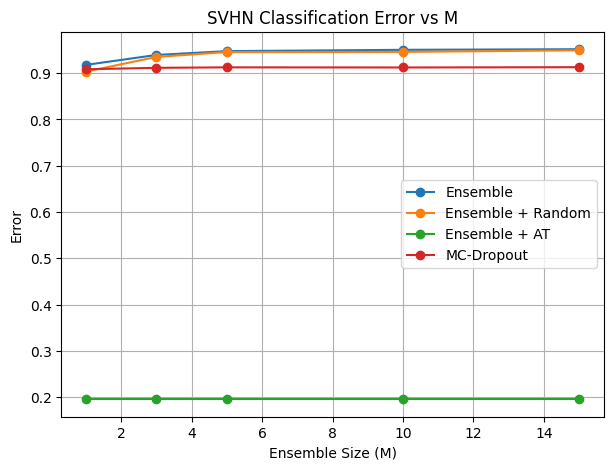

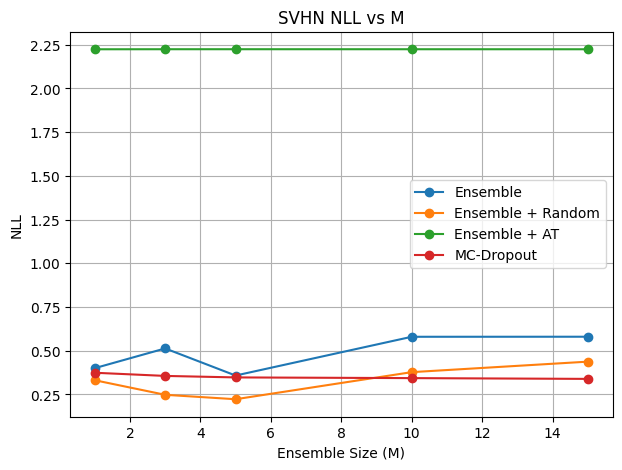

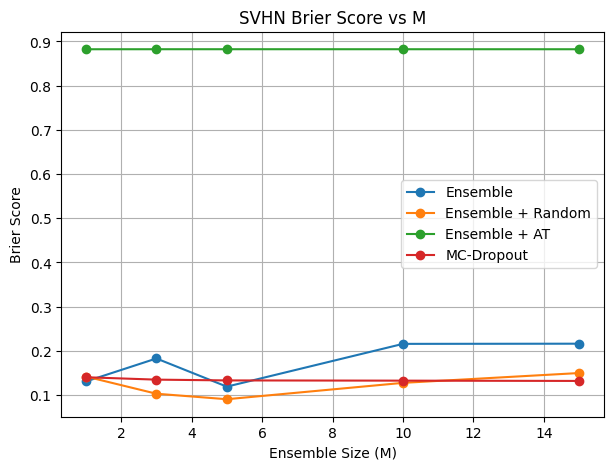

In [10]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

def plot_metric(Ms, results, metric_index, title, ylabel):
    plt.figure(figsize=(7,5))

    plt.plot(Ms, [results["ensemble"][i][metric_index] for i in range(len(Ms))],
             label="Ensemble", marker="o")
    plt.plot(Ms, [results["ensemble_random"][i][metric_index] for i in range(len(Ms))],
             label="Ensemble + Random", marker="o")
    plt.plot(Ms, [results["ensemble_adv"][i][metric_index] for i in range(len(Ms))],
             label="Ensemble + AT", marker="o")
    plt.plot(Ms, [results["mc_dropout"][i][metric_index] for i in range(len(Ms))],
             label="MC-Dropout", marker="o")

    plt.title(title)
    plt.xlabel("Ensemble Size (M)")
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.legend()
    plt.show()
plot_metric(Ms, results_svhn, 0, "SVHN Classification Error vs M", "Error")
plot_metric(Ms, results_svhn, 1, "SVHN NLL vs M", "NLL")
plot_metric(Ms, results_svhn, 2, "SVHN Brier Score vs M", "Brier Score")


Using: cuda
Training MNIST models...
Training model 1/15
Training model 2/15
Training model 3/15
Training model 4/15
Training model 5/15
Training model 6/15
Training model 7/15
Training model 8/15
Training model 9/15
Training model 10/15
Training model 11/15
Training model 12/15
Training model 13/15
Training model 14/15
Training model 15/15
NotMNIST already extracted.
Entropy for M=1
Skipping corrupted file: /kaggle/working/notMNIST_small/A/RGVtb2NyYXRpY2FCb2xkT2xkc3R5bGUgQm9sZC50dGY=.png
Skipping corrupted file: /kaggle/working/notMNIST_small/F/Q3Jvc3NvdmVyIEJvbGRPYmxpcXVlLnR0Zg==.png
Skipping corrupted file: /kaggle/working/notMNIST_small/A/RGVtb2NyYXRpY2FCb2xkT2xkc3R5bGUgQm9sZC50dGY=.png
Skipping corrupted file: /kaggle/working/notMNIST_small/F/Q3Jvc3NvdmVyIEJvbGRPYmxpcXVlLnR0Zg==.png
Entropy for M=5
Skipping corrupted file: /kaggle/working/notMNIST_small/A/RGVtb2NyYXRpY2FCb2xkT2xkc3R5bGUgQm9sZC50dGY=.png
Skipping corrupted file: /kaggle/working/notMNIST_small/F/Q3Jvc3NvdmVyIEJvbGRP

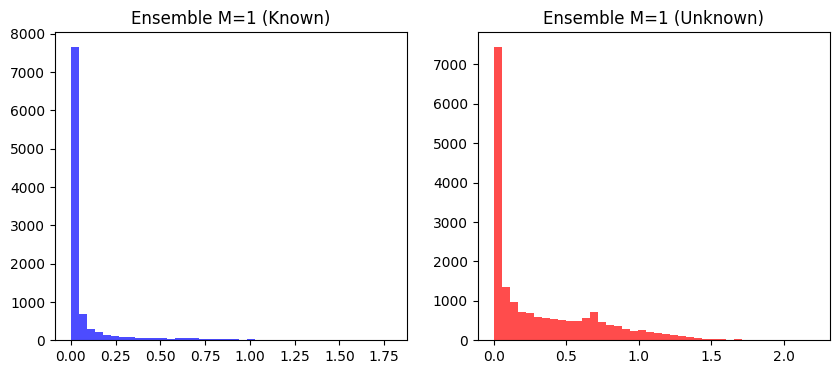

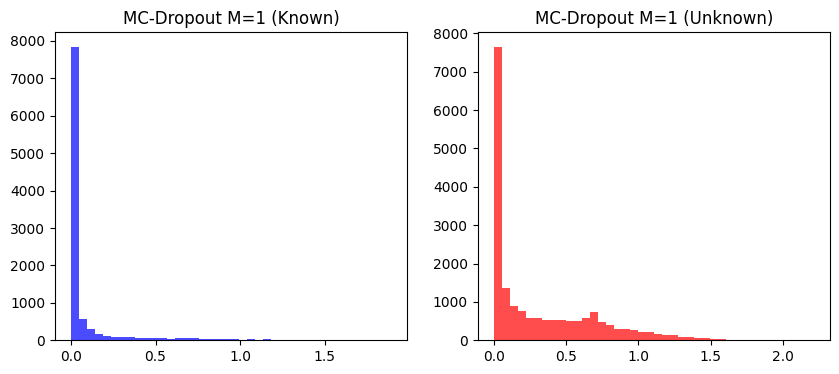

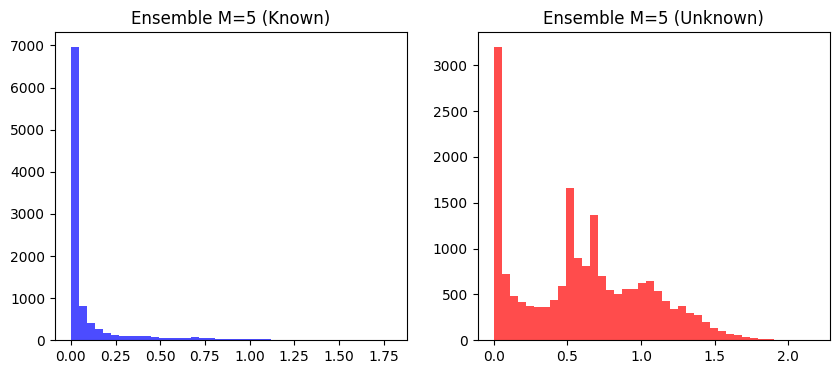

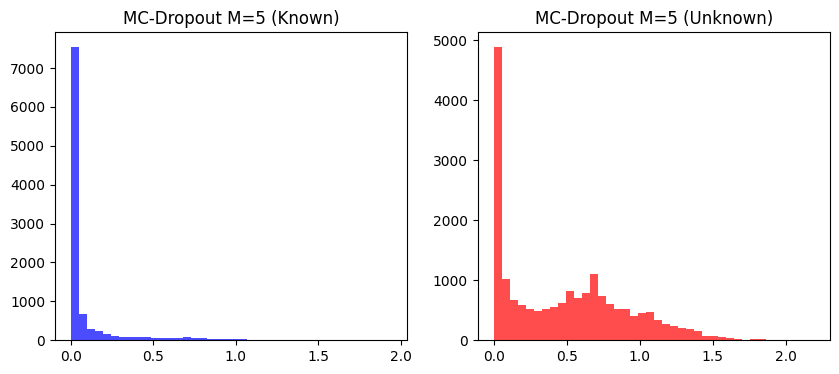

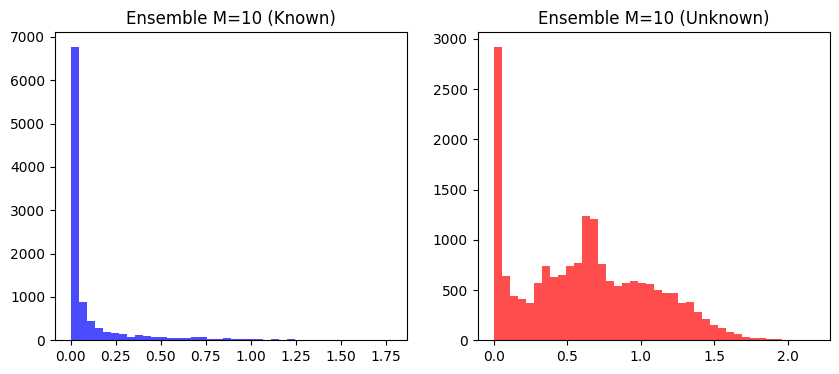

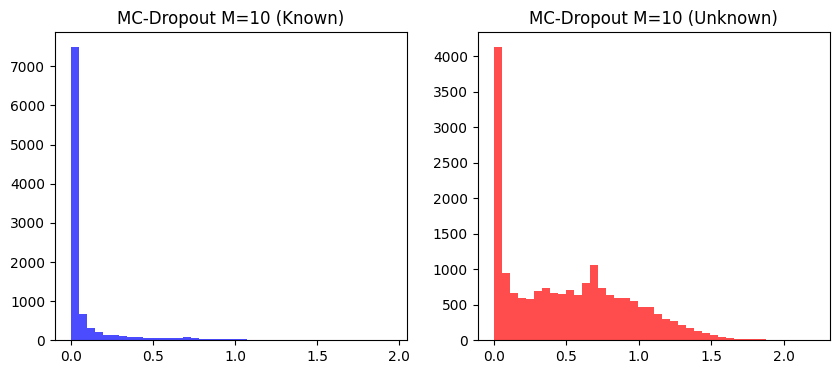

In [6]:
# ============================================================
#  SECTION 3.5 — MNIST (known) vs NotMNIST (unknown)
#  FULL WORKING VERSION WITH SAFE LOADER
# ============================================================

import os
import tarfile
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from PIL import Image, UnidentifiedImageError
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

# ============================================================
# SAFE IMAGE LOADER (SKIPS CORRUPTED FILES)
# ============================================================

def safe_loader(path):
    try:
        with open(path, "rb") as f:
            img = Image.open(f)
            return img.convert("L")
    except UnidentifiedImageError:
        print("Skipping corrupted file:", path)
        return None

class SafeImageFolder(datasets.ImageFolder):
    def __getitem__(self, index):
        path, target = self.samples[index]
        img = safe_loader(path)
        if img is None:
            img = Image.new("L", (28, 28))  # dummy image
        if self.transform is not None:
            img = self.transform(img)
        return img, target

# ============================================================
# MODEL DEFINITION (3-layer MLP)
# ============================================================

class MLP3(nn.Module):
    def __init__(self, dropout_p=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 200), nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(200, 200), nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(200, 200), nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(200, 10)
        )
    def forward(self, x):
        return self.net(x)

# ============================================================
# TRAINING FUNCTION
# ============================================================

def train_single_net(model, loader, epochs=3, lr=1e-3, adv_mode=None, epsilon=0.3):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    for ep in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            if adv_mode == "random":
                noise = epsilon * torch.sign(torch.randn_like(x))
                x = torch.clamp(x + noise, 0, 1)

            elif adv_mode == "adv":
                x.requires_grad = True
                logits = model(x)
                loss = F.cross_entropy(logits, y)
                loss.backward()
                grad = torch.sign(x.grad)
                x = torch.clamp(x + epsilon * grad, 0, 1).detach()

            logits = model(x)
            loss = F.cross_entropy(logits, y)

            opt.zero_grad()
            loss.backward()
            opt.step()

    return model

# ============================================================
# LOAD MNIST
# ============================================================

mnist_train = datasets.MNIST("./data", train=True, download=True, transform=transforms.ToTensor())
mnist_test = datasets.MNIST("./data", train=False, download=True, transform=transforms.ToTensor())

train_loader = DataLoader(mnist_train, batch_size=128, shuffle=True)
mnist_test_loader = DataLoader(mnist_test, batch_size=512, shuffle=False)

# ============================================================
# TRAIN ENSEMBLES (M = 15)
# ============================================================

NUM_NETS = 15
epsilon = 0.3

base_nets = []
base_nets_random = []
base_nets_adv = []

print("Training MNIST models...")

for i in range(NUM_NETS):
    print(f"Training model {i+1}/{NUM_NETS}")

    base_nets.append(train_single_net(MLP3(0.0), train_loader))
    base_nets_random.append(train_single_net(MLP3(0.0), train_loader, adv_mode="random", epsilon=epsilon))
    base_nets_adv.append(train_single_net(MLP3(0.0), train_loader, adv_mode="adv", epsilon=epsilon))

mc_model = train_single_net(MLP3(dropout_p=0.1), train_loader)

# ============================================================
# EXTRACT NOTMNIST TAR.GZ
# ============================================================

tar_path = "/kaggle/input/datasets/lubaroli/notmnist/notMNIST_small.tar.gz"
extract_path = "/kaggle/working/notMNIST_small"

if not os.path.exists(extract_path):
    print("Extracting NotMNIST...")
    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall("/kaggle/working/")
else:
    print("NotMNIST already extracted.")

# Load NotMNIST safely
notmnist = SafeImageFolder(
    root=extract_path,
    transform=transforms.Compose([
        transforms.Resize((28, 28)),
        transforms.ToTensor()
    ])
)
notmnist_loader = DataLoader(notmnist, batch_size=512, shuffle=False)

# ============================================================
# ENTROPY FUNCTIONS
# ============================================================

def predictive_entropy(probs):
    return -torch.sum(probs * torch.log(probs + 1e-8), dim=1)

def ensemble_predict(models, x):
    logits = []
    for m in models:
        m.eval()
        with torch.no_grad():
            logits.append(m(x.to(device)))
    logits = torch.stack(logits)
    return F.softmax(logits, dim=-1).mean(0)

def mc_dropout_predict(model, x, M=10):
    model.train()
    logits = []
    for _ in range(M):
        logits.append(model(x.to(device)))
    logits = torch.stack(logits)
    return F.softmax(logits, dim=-1).mean(0)

def compute_entropy(models, loader, mc_model=None, M=10, mode="ensemble"):
    ent = []
    for x, _ in loader:
        if mode == "ensemble":
            probs = ensemble_predict(models, x)
        else:
            probs = mc_dropout_predict(mc_model, x, M)
        ent.append(predictive_entropy(probs).detach().cpu())
    return torch.cat(ent).detach().cpu().numpy()

# ============================================================
# RUN ENTROPY EXPERIMENT (M = 1, 5, 10)
# ============================================================

Ms = [1, 5, 10]
entropy_results = {}

for M in Ms:
    print(f"Entropy for M={M}")

    entropy_results[f"ens_known_{M}"] = compute_entropy(base_nets[:M], mnist_test_loader)
    entropy_results[f"ens_unknown_{M}"] = compute_entropy(base_nets[:M], notmnist_loader)

    entropy_results[f"mc_known_{M}"] = compute_entropy(None, mnist_test_loader, mc_model, M, "mc")
    entropy_results[f"mc_unknown_{M}"] = compute_entropy(None, notmnist_loader, mc_model, M, "mc")

# ============================================================
# PLOT HISTOGRAMS LIKE FIGURE 3(a)
# ============================================================

def plot_entropy(ent_known, ent_unknown, title):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.hist(ent_known, bins=40, color='blue', alpha=0.7)
    plt.title(title + " (Known)")
    plt.subplot(1,2,2)
    plt.hist(ent_unknown, bins=40, color='red', alpha=0.7)
    plt.title(title + " (Unknown)")
    plt.show()

for M in Ms:
    plot_entropy(entropy_results[f"ens_known_{M}"],
                 entropy_results[f"ens_unknown_{M}"],
                 f"Ensemble M={M}")

    plot_entropy(entropy_results[f"mc_known_{M}"],
                 entropy_results[f"mc_unknown_{M}"],
                 f"MC-Dropout M={M}")


In [7]:
import seaborn as sns

def plot_entropy_density(ent_known, ent_unknown, title):
    plt.figure(figsize=(10,4))
    sns.kdeplot(ent_known, color='blue', label='Known', bw_adjust=0.5)
    sns.kdeplot(ent_unknown, color='red', label='Unknown', bw_adjust=0.5)
    plt.title(title)
    plt.xlabel("entropy values")
    plt.ylabel("density")
    plt.legend()
    plt.show()


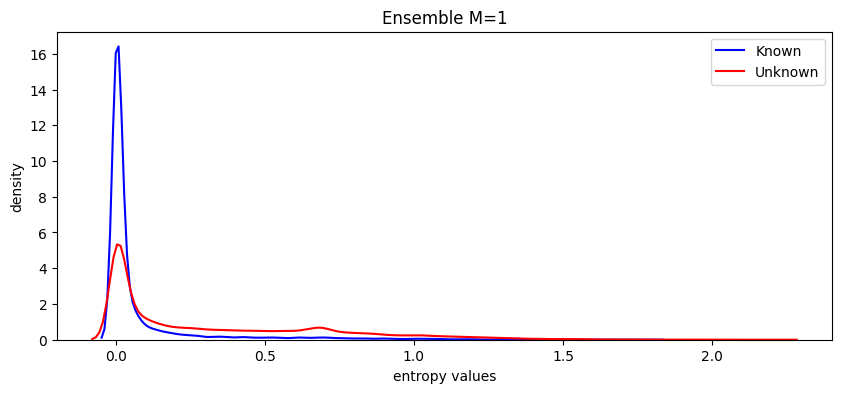

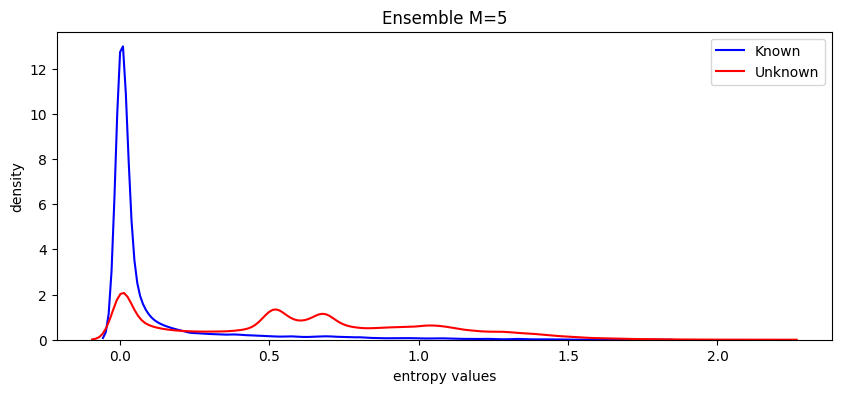

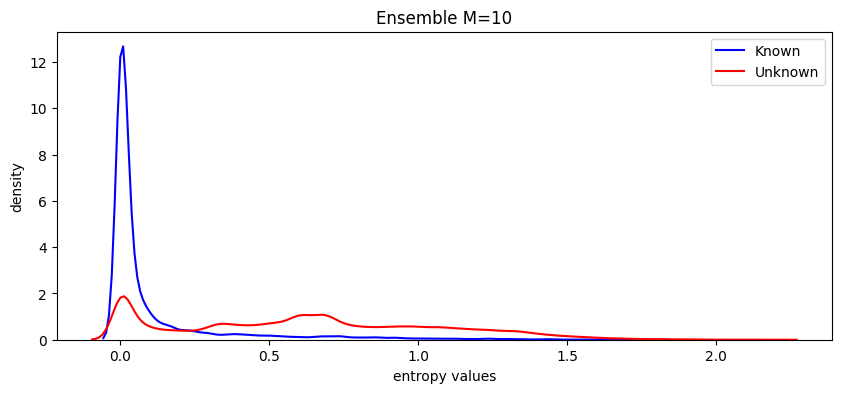

In [8]:
for M in Ms:
    plot_entropy_density(entropy_results[f"ens_known_{M}"],
                         entropy_results[f"ens_unknown_{M}"],
                         f"Ensemble M={M}")


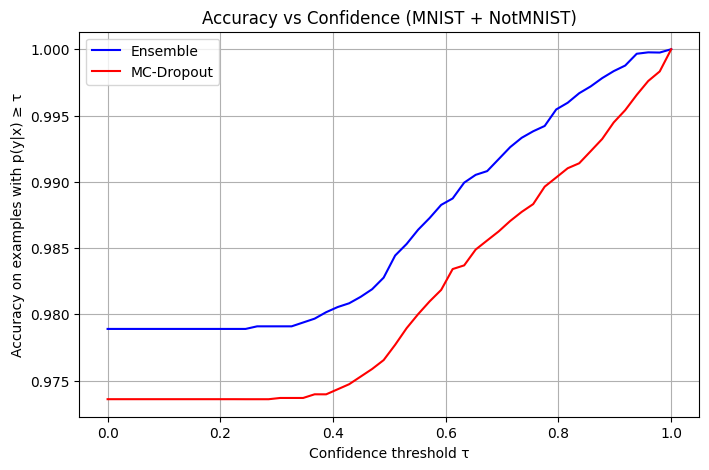

In [10]:
# ============================================================
#  SECTION 3.6 — Accuracy as a Function of Confidence
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

def evaluate_accuracy_vs_confidence(models, loader, mode="ensemble", mc_model=None, M=10, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.0, 1.0, 50)

    all_confidences = []
    all_correct = []

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        # ---- Ensemble or MC-Dropout prediction ----
        if mode == "ensemble":
            probs = ensemble_predict(models, x)
        else:
            probs = mc_dropout_predict(mc_model, x, M)

        # ---- FIX: detach before converting to numpy ----
        conf = probs.max(dim=1).values.detach().cpu().numpy()
        preds = probs.argmax(dim=1).detach().cpu().numpy()
        correct = (preds == y.detach().cpu().numpy()).astype(float)

        all_confidences.extend(conf)
        all_correct.extend(correct)

    all_confidences = np.array(all_confidences)
    all_correct = np.array(all_correct)

    # ---- Compute accuracy for each threshold ----
    accs = []
    for t in thresholds:
        mask = all_confidences >= t
        if mask.sum() == 0:
            accs.append(np.nan)
        else:
            accs.append(all_correct[mask].mean())

    return thresholds, np.array(accs)


# ============================================================
#  RUN ACCURACY vs CONFIDENCE FOR ENSEMBLE AND MC-DROPOUT
# ============================================================

thresholds, acc_ens = evaluate_accuracy_vs_confidence(
    base_nets[:10], mnist_test_loader, mode="ensemble"
)

_, acc_mc = evaluate_accuracy_vs_confidence(
    None, mnist_test_loader, mode="mc", mc_model=mc_model, M=10
)

# ============================================================
#  PLOT ACCURACY vs CONFIDENCE CURVES
# ============================================================

plt.figure(figsize=(8,5))
plt.plot(thresholds, acc_ens, label="Ensemble", color="blue")
plt.plot(thresholds, acc_mc, label="MC-Dropout", color="red")
plt.xlabel("Confidence threshold τ")
plt.ylabel("Accuracy on examples with p(y|x) ≥ τ")
plt.title("Accuracy vs Confidence (MNIST + NotMNIST)")
plt.legend()
plt.grid(True)
plt.show()
